In [135]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, callbacks, regularizers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from copy import deepcopy
from collections import Counter
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np



seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
tf.config.experimental.enable_op_determinism()

In [136]:

data_dir = "C:/Users/takat/Desktop/sotuken/dat_to_images_64"


label_dict = {
    # Mild (0)
    'AF483470.1.pbm': 0, 'EF192393.1.pbm': 0, 'EF192394.1.pbm': 0,
    'EF580923.1.pbm': 0, 'EU879915.1.pbm': 0, 'EU879916.1.pbm': 0,
    'JQ806338.1.pbm': 0, 'KF418767.1.pbm': 0, 'KR611355.1.pbm': 0,
    'KT987925.1.pbm': 0, 'LC388852.1.pbm': 0, 'LC388854.1.pbm': 0,
    'M25199.1.pbm': 0, 'MG450357.1.pbm': 0, 'Y09575.1.pbm': 0,

    # Moderate (1)
    'AF454395.1.pbm': 1, 'KF683200.1.pbm': 1, 'KJ857496.1.pbm': 1,
    'KR611360.1.pbm': 1, 'M88678.1.pbm': 1, 'X17268.1.pbm': 1,
    'GQ853461.1.pbm': 1, 'EU879913.1.pbm': 1,

    # Severe (2)
    'AJ634596.1.pbm': 2, 'AY518939.1.pbm': 2, 'AY532801.1.pbm': 2,
    'DD220185.1.pbm': 2, 'FR851463.1.pbm': 2, 'JX280944.1.pbm': 2,
    'U23060.1.pbm': 2, 'X58388.1.pbm': 2, 'X76846.1.pbm': 2,
    'X97387.1.pbm': 2, 'Y09383.1.pbm': 2, 'LC523672.1.pbm': 2,
    'LC523675.1.pbm': 2, 'LC523676.1.pbm': 2
}


labeled_pbm = list(label_dict.keys())
print(labeled_pbm)
labels = list(label_dict.values())


filepaths = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".pbm")]
print(len(filepaths))

labels_list = [label_dict.get(os.path.basename(fp), -1) for fp in filepaths]


IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 20
num_classes = 3
label_map = {0: "mild", 1: "moderate", 2: "severe"}



print(f"ラベル付きデータの数: {len(labeled_pbm)}")
print(f"全ファイル数: {len(filepaths)}")
print(f"未ラベルファイルの数: {labels_list.count(-1)}")

['AF483470.1.pbm', 'EF192393.1.pbm', 'EF192394.1.pbm', 'EF580923.1.pbm', 'EU879915.1.pbm', 'EU879916.1.pbm', 'JQ806338.1.pbm', 'KF418767.1.pbm', 'KR611355.1.pbm', 'KT987925.1.pbm', 'LC388852.1.pbm', 'LC388854.1.pbm', 'M25199.1.pbm', 'MG450357.1.pbm', 'Y09575.1.pbm', 'AF454395.1.pbm', 'KF683200.1.pbm', 'KJ857496.1.pbm', 'KR611360.1.pbm', 'M88678.1.pbm', 'X17268.1.pbm', 'GQ853461.1.pbm', 'EU879913.1.pbm', 'AJ634596.1.pbm', 'AY518939.1.pbm', 'AY532801.1.pbm', 'DD220185.1.pbm', 'FR851463.1.pbm', 'JX280944.1.pbm', 'U23060.1.pbm', 'X58388.1.pbm', 'X76846.1.pbm', 'X97387.1.pbm', 'Y09383.1.pbm', 'LC523672.1.pbm', 'LC523675.1.pbm', 'LC523676.1.pbm']
307
ラベル付きデータの数: 37
全ファイル数: 307
未ラベルファイルの数: 270


In [137]:
def load_and_preprocess_list(fp_list):
    X = []
    for p in fp_list:
        img = np.array(Image.open(p).convert('L').resize((64, 64)), dtype=np.float32)
        img = np.expand_dims(img, axis=-1)
        X.append(img)
    return np.array(X)

In [138]:
def load_and_preprocess_list_gabege(fp_list):
    X = []
    for p in fp_list:
        img = np.array(Image.open(p))
        img = img.reshape(64, 64, 1)
        img = img.astype('float32')
        img /= 1.0
        X.append(img)
    return np.array(X)

In [139]:
def make_model():
    model = models.Sequential()
    model.add(layers.Conv2D(16,(3,3), activation='relu', kernel_regularizer=regularizers.l2(0.01), input_shape=(64, 64, 1)))
    model.add(layers.MaxPool2D((2,2)))
    model.add(layers.Conv2D(32,(3,3), activation='relu'))
    model.add(layers.MaxPool2D((2,2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu', kernel_regularizer = regularizers.l2(0.01)))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(64, activation='relu', kernel_regularizer = regularizers.l2(0.01)))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

In [140]:
def jackknife_on_files(labeled_paths, labeled_labels, unlabeled_paths, epochs, verbose=1):
    n = len(labeled_paths)
    X_labeled = load_and_preprocess_list(labeled_paths)
    y_labeled = np.array(labeled_labels, dtype=np.int32)
    X_unlabeled = load_and_preprocess_list(unlabeled_paths)


    all_preds = {os.path.basename(fp): {"True_Label": label_map.get(lb, "")}
                 for fp, lb in zip(labeled_paths + unlabeled_paths, labels_list)}
    fixed_labels = ["mild", "moderate", "severe"]
    cm_list = []
    times = 10
    model = make_model()
    model.compile(optimizer=optimizers.Adam(1e-4),
                  loss=losses.SparseCategoricalCrossentropy(),
                  metrics=['sparse_categorical_accuracy'])
    for i in range(times):
        print(f"\n times:{i+1}/{n} ")
        fold_val_loss = []
        fold_val_acc = []
        pred_results = []
        for j in range(37):

            #i番目のデータを検証用、それ以外を学習用
            mask = np.arange(n) != j
            #print(mask)
            x_train, y_train = X_labeled[mask], y_labeled[mask]
            x_val, y_val = X_labeled[[j]], y_labeled[[j]]


            #モデル学習部分
            history = model.fit(x_train, y_train,validation_data=(x_val, y_val),batch_size = BATCH_SIZE, epochs=epochs, verbose=verbose)

            fold_val_loss.append(history.history['val_loss'][0])
            fold_val_acc.append(history.history['val_sparse_categorical_accuracy'][0])

            pred = model.predict(x_val)
            pred_results.append((labeled_paths[j],pred))

        pred_labels = []
        true_labels = []
        for k in range(len(pred_results)):
            pre = pred_results[k][1].tolist()
            pre = pre[0]
            pred_labels.append(pre.index(max(pre)))
            true_labels.append(label_dict[os.path.basename(pred_results[k][0])])
        cm = confusion_matrix(true_labels, pred_labels)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fixed_labels)
        disp.plot(cmap=plt.cm.Blues, values_format='d')
        plt.title(f"Confusion Matrix (Epoch {i+1})")
        plt.show()


        mean_val_loss = np.mean(fold_val_loss)
        mean_val_acc = np.mean(fold_val_acc)
        val_loss_history.append(mean_val_loss)
        val_acc_history.append(mean_val_acc)










C:\Users\takat\Desktop\sotuken\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 times:1/37 
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 299ms/step - loss: 20.6023 - sparse_categorical_accuracy: 0.3889 - val_loss: 1.9204 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 18.9757 - sparse_categorical_accuracy: 0.3889 - val_loss: 1.9065 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 10.2958 - sparse_categorical_accuracy: 0.5278 - val_loss: 1.8937 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 11.9142 - sparse_categorical_accuracy: 0.4722 - val_loss: 4.0116 - val_sparse_categorical_accuracy: 0.0000e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 9.4864 - sparse_categorical_accuracy: 0.5278 - val_loss: 12.3024 - val_sparse_categorical_accuracy: 0.0000e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
2/2 ━━━━━━━━━━━━━━

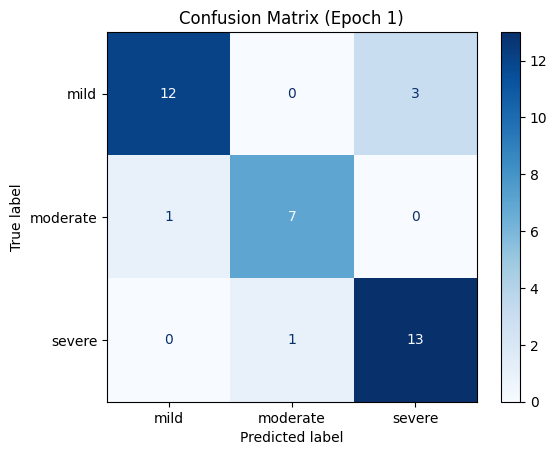


 times:2/37 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 2.0066 - sparse_categorical_accuracy: 0.8889 - val_loss: 2.8969 - val_sparse_categorical_accuracy: 0.0000e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 1.8891 - sparse_categorical_accuracy: 0.8611 - val_loss: 1.8642 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 2.0461 - sparse_categorical_accuracy: 0.7778 - val_loss: 1.8959 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 2.0700 - sparse_categorical_accuracy: 0.7500 - val_loss: 1.6472 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 2.0828 - sparse_categorical_accuracy: 0.6667 - val_loss: 1.8533 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s

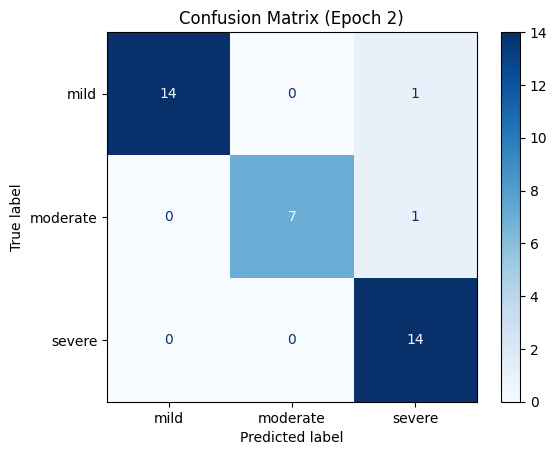


 times:3/37 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 1.7953 - sparse_categorical_accuracy: 0.7500 - val_loss: 1.6587 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 1.7335 - sparse_categorical_accuracy: 0.8333 - val_loss: 1.4539 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 1.8222 - sparse_categorical_accuracy: 0.8889 - val_loss: 1.4707 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 1.7743 - sparse_categorical_accuracy: 0.8611 - val_loss: 1.4073 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 1.6659 - sparse_categorical_accuracy: 0.9444 - val_loss: 1.4611 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106m

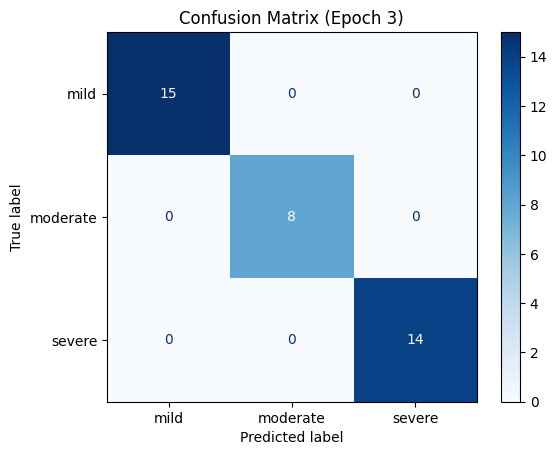


 times:4/37 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 1.5873 - sparse_categorical_accuracy: 0.8611 - val_loss: 1.4202 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 1.5842 - sparse_categorical_accuracy: 0.8889 - val_loss: 1.3601 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 1.5255 - sparse_categorical_accuracy: 0.9167 - val_loss: 1.4279 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 1.5078 - sparse_categorical_accuracy: 0.9444 - val_loss: 1.2983 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 1.4815 - sparse_categorical_accuracy: 0.9167 - val_loss: 1.3424 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106m

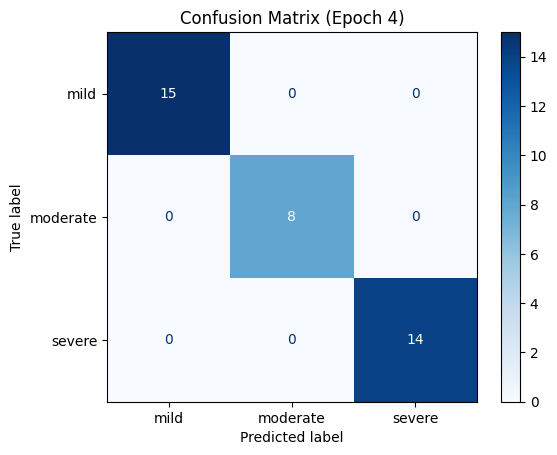


 times:5/37 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 1.3997 - sparse_categorical_accuracy: 0.9167 - val_loss: 1.4017 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 1.4115 - sparse_categorical_accuracy: 0.9722 - val_loss: 1.2904 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 1.5677 - sparse_categorical_accuracy: 0.8611 - val_loss: 1.2849 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 1.3867 - sparse_categorical_accuracy: 0.8889 - val_loss: 1.2456 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 1.4763 - sparse_categorical_accuracy: 0.8889 - val_loss: 1.2709 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98m

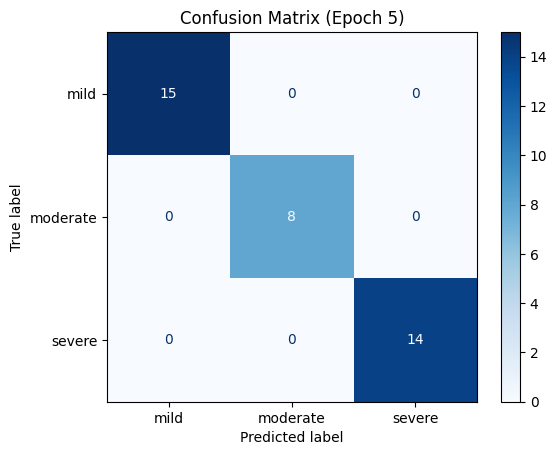


 times:6/37 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 1.4071 - sparse_categorical_accuracy: 0.9167 - val_loss: 1.2169 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 1.3385 - sparse_categorical_accuracy: 0.9444 - val_loss: 1.2208 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 1.3863 - sparse_categorical_accuracy: 0.9167 - val_loss: 1.2257 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 1.3376 - sparse_categorical_accuracy: 0.9167 - val_loss: 1.2187 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 1.3228 - sparse_categorical_accuracy: 0.9722 - val_loss: 1.2305 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105m

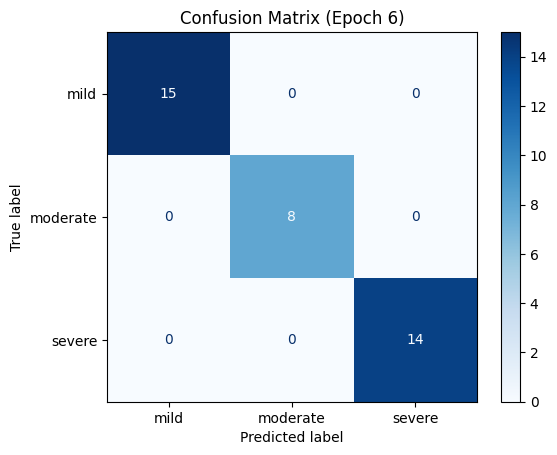


 times:7/37 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 1.3208 - sparse_categorical_accuracy: 0.9444 - val_loss: 1.2085 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 1.3390 - sparse_categorical_accuracy: 0.9722 - val_loss: 1.1887 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 1.2798 - sparse_categorical_accuracy: 0.9722 - val_loss: 1.2057 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 1.3938 - sparse_categorical_accuracy: 0.8889 - val_loss: 1.1848 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 1.4205 - sparse_categorical_accuracy: 0.9167 - val_loss: 1.1928 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106

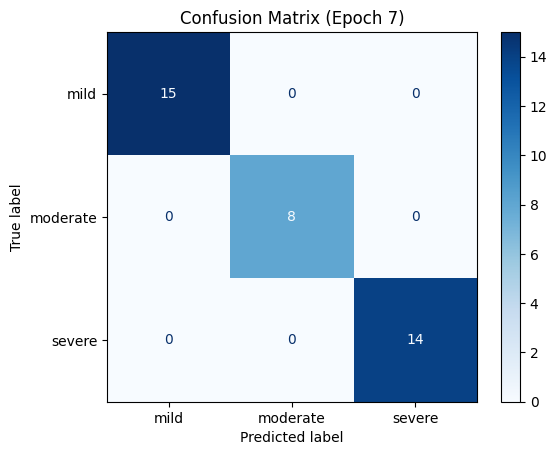


 times:8/37 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 1.3536 - sparse_categorical_accuracy: 0.8889 - val_loss: 1.2006 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 1.4582 - sparse_categorical_accuracy: 0.7778 - val_loss: 1.1697 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 1.3150 - sparse_categorical_accuracy: 0.9444 - val_loss: 1.2594 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 1.3178 - sparse_categorical_accuracy: 0.9167 - val_loss: 1.1656 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 1.3267 - sparse_categorical_accuracy: 0.9167 - val_loss: 1.1859 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/

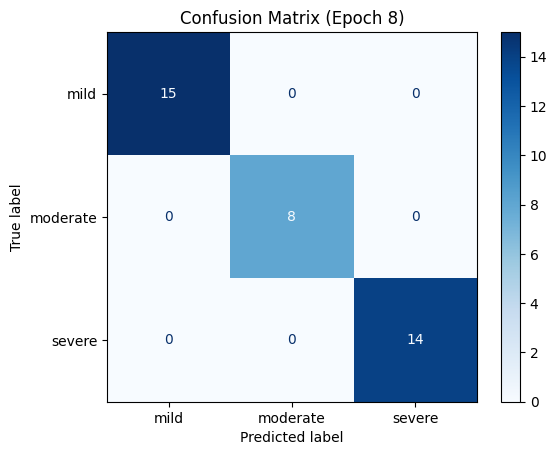


 times:9/37 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 1.2546 - sparse_categorical_accuracy: 0.9444 - val_loss: 1.1588 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 1.2733 - sparse_categorical_accuracy: 0.9444 - val_loss: 1.1445 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 1.4766 - sparse_categorical_accuracy: 0.8889 - val_loss: 1.1559 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 1.4140 - sparse_categorical_accuracy: 0.8611 - val_loss: 1.1484 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 1.3804 - sparse_categorical_accuracy: 0.8889 - val_loss: 1.1435 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101

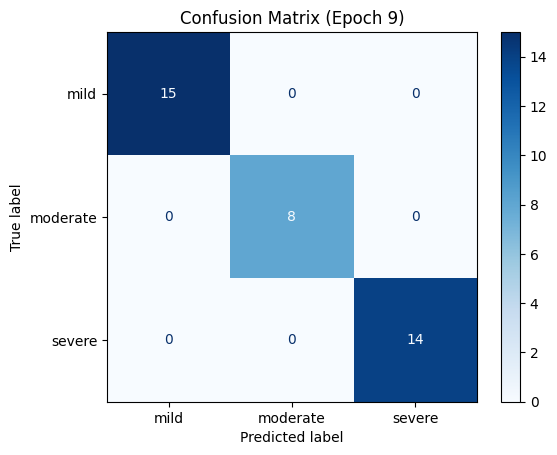


 times:10/37 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 1.2758 - sparse_categorical_accuracy: 0.9167 - val_loss: 1.1237 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 1.2319 - sparse_categorical_accuracy: 0.9444 - val_loss: 1.1244 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 1.2847 - sparse_categorical_accuracy: 0.9167 - val_loss: 1.1274 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 1.2215 - sparse_categorical_accuracy: 0.9444 - val_loss: 1.1263 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 1.2612 - sparse_categorical_accuracy: 0.9167 - val_loss: 1.1311 - val_sparse_categorical_accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104m

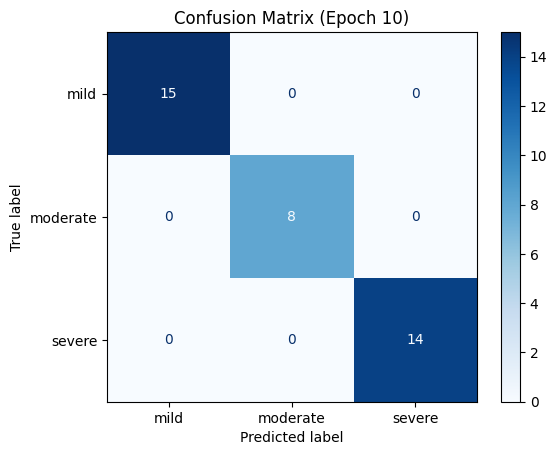

finish


In [141]:
labeled_fullpaths = [os.path.join(data_dir, name) for name in labeled_pbm]
unlabeled_fullpaths = [fp for fp, lb in zip(filepaths, labels_list) if lb == -1]

results = []
pred_results = []
val_loss_history = []
val_acc_history = []

jackknife_on_files(labeled_fullpaths, labels, unlabeled_fullpaths, epochs=1, verbose=1)

print("finish")

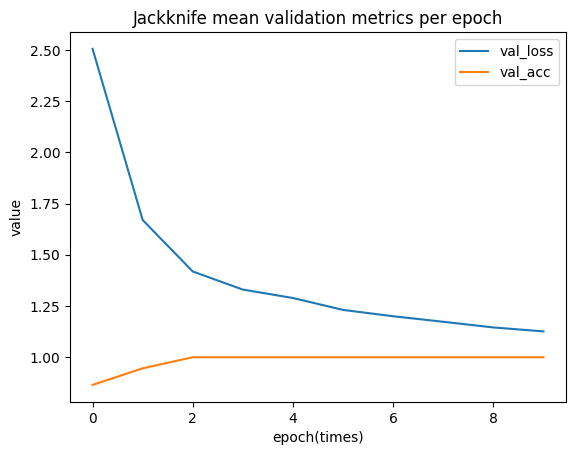

In [142]:
#for i in range(len(results)):
 #   plt.plot(results[i]['sparse_categorical_accuracy'], label='accuracy')
  #  plt.xlabel('Epoch')
   # plt.ylabel('Accuracy')
    #plt.ylim([0, 1])
     #plt.legend(loc='lower right')
plt.plot(val_loss_history, label="val_loss")
plt.plot(val_acc_history, label="val_acc")
plt.xlabel("epoch(times)")
plt.ylabel("value")
plt.legend()
plt.title("Jackknife mean validation metrics per epoch")
plt.show()

In [143]:
'''
#print(pred_results)
pred_labels = []
true_labels = []
for i in range(len(pred_results)):
    pre = pred_results[i][1].tolist()
    pre = pre[0]
    pred_labels.append(pre.index(max(pre)))
    true_labels.append(label_dict[pred_results[i][0]])
    #print(pred_labels[i],true_labels[i])

fixed_labels = ["mild", "moderate", "severe"]
cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fixed_labels)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("labeled matrix 37fold")
plt.show()
'''

'\n#print(pred_results)\npred_labels = []\ntrue_labels = []\nfor i in range(len(pred_results)):\n    pre = pred_results[i][1].tolist()\n    pre = pre[0]\n    pred_labels.append(pre.index(max(pre)))\n    true_labels.append(label_dict[pred_results[i][0]])\n    #print(pred_labels[i],true_labels[i])\n\nfixed_labels = ["mild", "moderate", "severe"]\ncm = confusion_matrix(true_labels, pred_labels)\ndisp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fixed_labels)\ndisp.plot(cmap=plt.cm.Blues, values_format=\'d\')\nplt.title("labeled matrix 37fold")\nplt.show()\n'

Epoch 1/100


C:\Users\takat\Desktop\sotuken\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 31.1264 - sparse_categorical_accuracy: 0.2973
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 18.5018 - sparse_categorical_accuracy: 0.4054
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 11.9630 - sparse_categorical_accuracy: 0.4865
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 9.0884 - sparse_categorical_accuracy: 0.5135 
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 12.7591 - sparse_categorical_accuracy: 0.5135
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 10.1348 - sparse_categorical_accuracy: 0.4324
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 9.9069 - sparse_categorical_accuracy: 0.4595 
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 7.3400 - sparse_categorical_accuracy: 0.4595
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 9.3155 - sparse_categorical_accuracy: 0.4324
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 6.0254 - sparse_cat

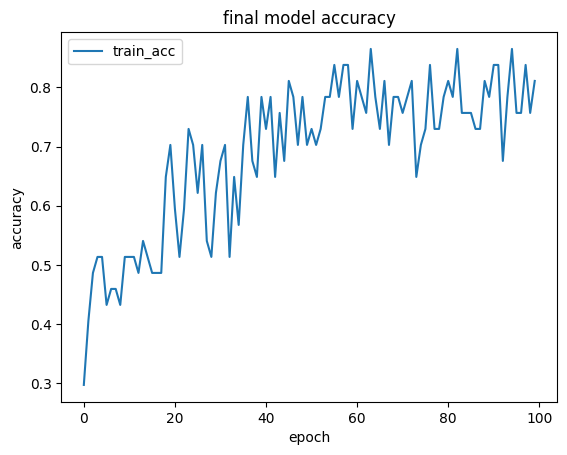

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
finish


In [144]:
final_model = make_model()
final_model.compile(optimizer=optimizers.Adam(1e-4),
                    loss=losses.SparseCategoricalCrossentropy(),
                    metrics=['sparse_categorical_accuracy'])

x_all = load_and_preprocess_list(labeled_fullpaths)
y_all = np.array(labels, dtype = np.int32)
final_history = final_model.fit(x_all, y_all,batch_size = BATCH_SIZE,epochs = 100,verbose=1)


plt.plot(final_history.history["sparse_categorical_accuracy"], label="train_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("final model accuracy")
plt.legend()
plt.show()

final_model.save("jackknife_PSTVd_model.keras")

X_unlabeled = load_and_preprocess_list(unlabeled_fullpaths)

unlabeled_preds = final_model.predict(X_unlabeled)
pred_classes = np.argmax(unlabeled_preds, axis=1)
pred_labels = [label_map[c] for c in pred_classes]

df_pred = pd.DataFrame({
    "PBM_Name": [os.path.basename(fp) for fp in unlabeled_fullpaths],
    "Pred_Sym_Severity": pred_labels
})
df_pred.to_csv("1e-4.csv", index=False)
print("finish")
